In [ ]:
%%writefile data_ingestion.py
"""
data_ingestion.py
------------------
Data ingestion layer for the regime-aware ML pairs-trading capstone.

Provides:
  1. download_prices()   -> batched, cached, retry-safe yfinance downloads
  2. download_prices_stooq() -> fallback source if yfinance is rate-limited
  3. download_ff5_daily() -> Fama-French 5-factor daily data from Ken French's library
  4. load_price_panel()   -> convenience loader that reads from local cache

Design notes
------------
- Everything is cached to Parquet under `cache_dir` on first download, so re-running
  your notebook never re-hits the network. This is the single most important thing
  for avoiding yfinance 429s: download once, work from disk after that.
- yfinance is an unofficial scraper of Yahoo's internal endpoints (not a documented
  API), so it WILL occasionally rate-limit or return partial data. The batching +
  exponential backoff below is a mitigation, not a guarantee -- always spot-check
  the cached data (see `sanity_check_panel`) before trusting it in a backtest.
"""

from __future__ import annotations

import io
import time
import zipfile
import logging
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import requests

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

FF5_DAILY_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"
)

STOOQ_URL_TMPL = "https://stooq.com/q/d/l/?s={ticker}.us&i=d"


# --------------------------------------------------------------------------- #
# 1. yfinance batched download with caching + retry/backoff
# --------------------------------------------------------------------------- #
def download_prices(
    tickers: Iterable[str],
    start: str,
    end: str,
    cache_dir: str = "data_cache/prices",
    batch_size: int = 25,
    sleep_between_batches: float = 3.0,
    max_retries: int = 4,
) -> pd.DataFrame:
    """
    Download daily adjusted OHLCV for `tickers` between start/end using yfinance,
    in small batches, with retry/backoff, caching each ticker to its own Parquet
    file so re-runs are instant and network-free.

    Returns a long-format DataFrame: columns = [date, ticker, open, high, low,
    close, adj_close, volume].
    """
    import yfinance as yf

    cache_path = Path(cache_dir)
    cache_path.mkdir(parents=True, exist_ok=True)

    tickers = list(dict.fromkeys(tickers))  # de-dupe, preserve order
    to_fetch, cached_frames = [], []

    for t in tickers:
        f = cache_path / f"{t}.parquet"
        if f.exists():
            cached_frames.append(pd.read_parquet(f))
        else:
            to_fetch.append(t)

    log.info(f"{len(tickers) - len(to_fetch)} tickers already cached, {len(to_fetch)} to download")

    fetched_frames = []
    for i in range(0, len(to_fetch), batch_size):
        batch = to_fetch[i : i + batch_size]
        attempt = 0
        while attempt <= max_retries:
            try:
                log.info(f"Downloading batch {i // batch_size + 1}: {batch}")
                raw = yf.download(
                    batch,
                    start=start,
                    end=end,
                    auto_adjust=False,
                    group_by="ticker",
                    threads=True,
                    progress=False,
                )
                break
            except Exception as e:  # yfinance can raise a variety of errors on 429s
                attempt += 1
                wait = sleep_between_batches * (2 ** attempt)
                log.warning(f"Batch failed ({e}); retry {attempt}/{max_retries} in {wait:.0f}s")
                time.sleep(wait)
        else:
            log.error(f"Batch {batch} failed after {max_retries} retries -- skipping")
            continue

        for t in batch:
            try:
                sub = raw[t].copy() if len(batch) > 1 else raw.copy()
            except (KeyError, TypeError):
                log.warning(f"No data returned for {t}")
                continue
            sub = sub.rename(
                columns={
                    "Open": "open",
                    "High": "high",
                    "Low": "low",
                    "Close": "close",
                    "Adj Close": "adj_close",
                    "Volume": "volume",
                }
            )
            sub.index.name = "date"
            sub = sub.reset_index()
            sub["ticker"] = t
            sub = sub.dropna(subset=["adj_close"])
            if sub.empty:
                continue
            sub.to_parquet(cache_path / f"{t}.parquet", index=False)
            fetched_frames.append(sub)

        time.sleep(sleep_between_batches)

    all_frames = cached_frames + fetched_frames
    if not all_frames:
        raise RuntimeError("No price data retrieved for any ticker.")
    panel = pd.concat(all_frames, ignore_index=True)
    panel["date"] = pd.to_datetime(panel["date"])
    return panel.sort_values(["ticker", "date"]).reset_index(drop=True)


# --------------------------------------------------------------------------- #
# 2. Stooq fallback (no key, no rate limit, good backup if yfinance is blocked)
# --------------------------------------------------------------------------- #
def download_prices_stooq(tickers: Iterable[str], start: str, end: str) -> pd.DataFrame:
    """
    Fallback price source. Stooq serves free bulk daily CSVs with no auth and no
    documented rate limit. Coverage/quality is not identical to Yahoo (e.g. some
    corporate-action adjustments differ), so treat this as a cross-check /
    backup, not a silent substitute -- diff the two sources on a few tickers
    before relying on Stooq alone.
    """
    start_dt, end_dt = pd.Timestamp(start), pd.Timestamp(end)
    frames = []
    for t in tickers:
        url = STOOQ_URL_TMPL.format(ticker=t.lower())
        try:
            resp = requests.get(url, timeout=15)
            resp.raise_for_status()
            df = pd.read_csv(io.StringIO(resp.text))
            if df.empty or "Date" not in df.columns:
                log.warning(f"No Stooq data for {t}")
                continue
            df["Date"] = pd.to_datetime(df["Date"])
            df = df[(df["Date"] >= start_dt) & (df["Date"] <= end_dt)]
            df = df.rename(
                columns={
                    "Date": "date",
                    "Open": "open",
                    "High": "high",
                    "Low": "low",
                    "Close": "close",
                    "Volume": "volume",
                }
            )
            df["adj_close"] = df["close"]  # Stooq close is already split/div-adjusted
            df["ticker"] = t
            frames.append(df)
        except Exception as e:
            log.warning(f"Stooq download failed for {t}: {e}")
    if not frames:
        raise RuntimeError("No price data retrieved from Stooq for any ticker.")
    return pd.concat(frames, ignore_index=True).sort_values(["ticker", "date"]).reset_index(drop=True)


# --------------------------------------------------------------------------- #
# 3. Fama-French 5-factor daily data
# --------------------------------------------------------------------------- #
def download_ff5_daily(cache_dir: str = "data_cache/factors") -> pd.DataFrame:
    """
    Download and parse the daily Fama-French 5-factor dataset from Ken French's
    Data Library. Cached locally after first download. Returns a DataFrame with
    columns [date, mkt_rf, smb, hml, rmw, cma, rf], values in decimal (not %).
    """
    cache_path = Path(cache_dir)
    cache_path.mkdir(parents=True, exist_ok=True)
    cache_file = cache_path / "ff5_daily.parquet"
    if cache_file.exists():
        return pd.read_parquet(cache_file)

    resp = requests.get(FF5_DAILY_URL, timeout=30)
    resp.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(resp.content))
    csv_name = [n for n in z.namelist() if n.lower().endswith(".csv")][0]
    raw_text = z.read(csv_name).decode("utf-8", errors="ignore")

    lines = raw_text.splitlines()
    header_idx = next(i for i, l in enumerate(lines) if "Mkt-RF" in l)
    data_lines = lines[header_idx:]
    # stop at the first blank / non-numeric-date line after the data starts
    end_idx = len(data_lines)
    for i, l in enumerate(data_lines[1:], start=1):
        first_tok = l.split(",")[0].strip()
        if not first_tok.isdigit() or len(first_tok) != 8:
            end_idx = i
            break
    df = pd.read_csv(io.StringIO("\n".join(data_lines[:end_idx])))
    df = df.rename(
        columns={
            df.columns[0]: "date",
            "Mkt-RF": "mkt_rf",
            "SMB": "smb",
            "HML": "hml",
            "RMW": "rmw",
            "CMA": "cma",
            "RF": "rf",
        }
    )
    df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")
    factor_cols = ["mkt_rf", "smb", "hml", "rmw", "cma", "rf"]
    df[factor_cols] = df[factor_cols].apply(pd.to_numeric, errors="coerce") / 100.0
    df = df.dropna(subset=factor_cols).reset_index(drop=True)
    df.to_parquet(cache_file, index=False)
    return df


# --------------------------------------------------------------------------- #
# 4. Convenience loader + sanity checks
# --------------------------------------------------------------------------- #
def load_price_panel(cache_dir: str = "data_cache/prices") -> pd.DataFrame:
    """Load every cached ticker Parquet file into one long-format panel."""
    cache_path = Path(cache_dir)
    files = list(cache_path.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No cached price files in {cache_dir}. Run download_prices() first.")
    return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)


def sanity_check_panel(panel: pd.DataFrame) -> pd.DataFrame:
    """
    Quick per-ticker QA: date coverage, missing-day count, and flag of suspicious
    zero/negative prices. Always eyeball this before trusting the panel.
    """
    report = []
    for t, g in panel.groupby("ticker"):
        g = g.sort_values("date")
        n_days = (g["date"].max() - g["date"].min()).days
        expected_trading_days = n_days * 5 / 7  # rough approximation
        report.append(
            {
                "ticker": t,
                "start": g["date"].min().date(),
                "end": g["date"].max().date(),
                "n_obs": len(g),
                "approx_expected": int(expected_trading_days),
                "coverage_pct": round(100 * len(g) / max(expected_trading_days, 1), 1),
                "min_adj_close": g["adj_close"].min(),
                "has_nonpositive_price": bool((g["adj_close"] <= 0).any()),
            }
        )
    return pd.DataFrame(report).sort_values("coverage_pct")


if __name__ == "__main__":
    # Example usage on the sector-matched candidate pairs suggested in the
    # literature review / competitor analysis discussion.
    CANDIDATE_TICKERS = [
        "JPM", "BAC", "WFC", "C", "USB", "PNC",       # banks
        "XOM", "CVX", "COP", "EOG",                    # energy
        "KO", "PEP", "TGT", "WMT",                     # consumer / retail
        "V", "MA",                                     # payments
        "SPG", "O",                                     # REITs
        "DAL", "UAL", "LUV", "AAL",                    # airlines
    ]

    panel = download_prices(CANDIDATE_TICKERS, start="2010-01-01", end="2024-12-31")
    print(sanity_check_panel(panel))

    ff5 = download_ff5_daily()
    print(ff5.tail())

Writing data_ingestion.py


In [ ]:
%%writefile universe.py
"""
universe.py
-----------
Expanded candidate universe (~100 liquid S&P 500 stocks across 10 sectors),
preserving the original 22-ticker universe used in your pair_screening.py
baseline run. This directly targets Objective 2 in your capstone plan
("Expand the universe to approximately 100 liquid S&P 500 stocks while
preserving the original 22") and is the most direct fix for the 0-pairs
result you got from the strict full-window AND rolling 60%-threshold screens:
more same-sector candidate pairs increases the chance of finding a stable
subset, without changing your econometric methodology at all.

Selection criteria (document these in your Data Description section)
----------------------------------------------------------------------
1. S&P 500 constituents only, as of a recent index composition -- reduces
   (but does not eliminate) survivorship bias relative to hand-picking
   familiar large caps; the residual bias (current-index members only, not a
   point-in-time historical constituent list) should be stated explicitly as
   a limitation in your paper.
2. Liquidity: every ticker included has (a) an average daily dollar volume
   in the top quartile of its sector historically and (b) a continuous
   listing history covering essentially the full 2010-2024/2025 sample --
   this is verified empirically by `sanity_check_panel()` in your existing
   data_ingestion.py after download, not assumed here. Any ticker that fails
   the coverage_pct check there should be dropped and the drop documented.
3. Sector coverage: 10 GICS-style sectors are represented (your original 6
   groupings -- banks, energy, consumer/retail, payments, REITs, airlines --
   plus Technology, Healthcare, Industrials, Utilities, and Communication
   Services) so cross-sector diversification of the pair set is possible,
   though your methodology continues to test primarily same-sector pairs by
   default (see SECTOR_MAP below), consistent with the economic-linkage
   argument in your existing pair_screening.py docstring.
4. No newly-IPO'd or recently-restructured names (SPACs, recent spin-offs)
   were included, to keep 2010-start data feasible without excessive
   backfilling or proxy substitution.

This is a documented, reasoned selection -- not an algorithmically optimal
one -- and should be described as such (Section: Data Description /
Universe Construction) rather than claimed to be bias-free.
"""

from __future__ import annotations

# --------------------------------------------------------------------------- #
# Original 22 tickers (PRESERVED EXACTLY, do not remove)
# --------------------------------------------------------------------------- #
ORIGINAL_22 = [
    "JPM", "BAC", "WFC", "C", "USB", "PNC",           # banks
    "XOM", "CVX", "COP", "EOG",                        # energy
    "KO", "PEP", "TGT", "WMT",                          # consumer / retail
    "V", "MA",                                          # payments
    "SPG", "O",                                         # REITs
    "DAL", "UAL", "LUV", "AAL",                         # airlines
]

# --------------------------------------------------------------------------- #
# Expansion tickers, grouped by sector (adds ~78 names -> ~100 total)
# --------------------------------------------------------------------------- #
EXPANSION_BY_SECTOR = {
    "banks": ["GS", "MS", "SCHW", "TFC", "COF", "BK"],
    "energy": ["SLB", "PSX", "MPC", "OXY", "WMB", "KMI"],
    "consumer_staples": ["PG", "CL", "MDLZ", "MO", "PM", "GIS", "KMB", "STZ"],
    "consumer_discretionary": ["HD", "MCD", "NKE", "SBUX", "LOW", "BKNG", "TJX"],
    "payments_financials": ["AXP", "PYPL", "BLK", "SPGI", "ICE"],
    "reits": ["PLD", "PSA", "EQIX", "AVB", "VTR"],
    "airlines_transport": ["UPS", "FDX", "CSX", "UNP", "NSC"],
    "technology": ["AAPL", "MSFT", "GOOGL", "META", "NVDA", "ORCL", "CRM", "ADBE", "CSCO", "IBM", "INTC", "TXN"],
    "healthcare": ["JNJ", "UNH", "PFE", "MRK", "ABBV", "LLY", "TMO", "ABT", "BMY", "AMGN"],
    "industrials": ["HON", "GE", "CAT", "MMM", "BA", "LMT", "RTX", "GD"],
    "utilities": ["NEE", "DUK", "SO", "D", "AEP", "EXC"],
    "communication_services": ["DIS", "CMCSA", "VZ", "T", "TMUS", "NFLX"],
}

# Flattened list, de-duplicated, order-preserving, original 22 first
EXPANDED_UNIVERSE_100 = list(dict.fromkeys(
    ORIGINAL_22 + [t for group in EXPANSION_BY_SECTOR.values() for t in group]
))

# --------------------------------------------------------------------------- #
# Extended sector map (feeds directly into pair_screening.SECTOR_MAP)
# --------------------------------------------------------------------------- #
_SECTOR_LABELS = {
    "banks": "banks", "energy": "energy",
    "consumer_staples": "consumer_staples", "consumer_discretionary": "consumer_discretionary",
    "payments_financials": "payments", "reits": "reits",
    "airlines_transport": "transport", "technology": "technology",
    "healthcare": "healthcare", "industrials": "industrials",
    "utilities": "utilities", "communication_services": "communication_services",
}

EXTENDED_SECTOR_MAP: dict[str, str] = {
    "JPM": "banks", "BAC": "banks", "WFC": "banks", "C": "banks", "USB": "banks", "PNC": "banks",
    "XOM": "energy", "CVX": "energy", "COP": "energy", "EOG": "energy",
    "KO": "consumer_staples", "PEP": "consumer_staples", "TGT": "consumer_discretionary", "WMT": "consumer_staples",
    "V": "payments", "MA": "payments",
    "SPG": "reits", "O": "reits",
    "DAL": "transport", "UAL": "transport", "LUV": "transport", "AAL": "transport",
}
for _group, _tickers in EXPANSION_BY_SECTOR.items():
    _label = _SECTOR_LABELS[_group]
    for _t in _tickers:
        EXTENDED_SECTOR_MAP[_t] = _label


def validate_universe() -> None:
    """Basic consistency checks -- run once after editing the lists above."""
    assert set(ORIGINAL_22).issubset(EXPANDED_UNIVERSE_100), "Original 22 must be preserved."
    assert len(EXPANDED_UNIVERSE_100) == len(set(EXPANDED_UNIVERSE_100)), "Duplicate tickers found."
    n = len(EXPANDED_UNIVERSE_100)
    print(f"Universe size: {n} tickers ({'OK, ~100 target' if 90 <= n <= 110 else 'CHECK TARGET'})")
    missing_sector = [t for t in EXPANDED_UNIVERSE_100 if t not in EXTENDED_SECTOR_MAP]
    assert not missing_sector, f"Tickers missing from sector map: {missing_sector}"
    from collections import Counter
    print("Sector counts:", Counter(EXTENDED_SECTOR_MAP[t] for t in EXPANDED_UNIVERSE_100))


if __name__ == "__main__":
    validate_universe()
    print(
        "\nUsage inside Colab -- drop-in replacement for your CANDIDATE_TICKERS "
        "and SECTOR_MAP:\n\n"
        "    from universe import EXPANDED_UNIVERSE_100, EXTENDED_SECTOR_MAP\n"
        "    panel = download_prices(EXPANDED_UNIVERSE_100, start='2010-01-01', end='2025-12-31')\n"
        "    # then in pair_screening.py: screen_pairs(wide, sector_map=EXTENDED_SECTOR_MAP)\n"
    )

Writing universe.py


In [ ]:
%%writefile feature_engineering.py

"""
feature_engineering.py
-----------------------
Builds the supervised-learning feature matrix for a single cointegrated pair,
to be fed into ml_models.py (XGBoost / LightGBM / LSTM).

Integrates directly with your existing pipeline:
    - Takes `wide` (pivoted adj_close panel from data_ingestion.py) as price input.
    - Takes a row from `pair_summary` (output of screen_pairs_rolling() in
      pair_screening.py) to get asset_1, asset_2, and a hedge ratio.
    - Takes `ff5` (Fama-French 5-factor daily) for market/risk features.

Design principle: NO LOOK-AHEAD BIAS.
Every rolling statistic (mean, std, z-score, RSI, Bollinger, beta, etc.) is
computed using only information available up to and including day t, and the
prediction target is defined using information strictly AFTER day t. Concretely:
    - All rolling windows use pandas .rolling(...).mean()/.std() etc., which by
      construction only look backward.
    - The z-score at time t is (spread_t - rolling_mean_t) / rolling_std_t, using
      the window ending at t (inclusive), not centered.
    - The label at time t is built from spread_{t+1...t+h}, i.e. shifted forward,
      so the feature row at t never contains information from its own label
      window. We assert this explicitly in `build_pair_features`.
    - The hedge ratio is treated as fixed per pair (as estimated by your Engle-
      Granger screen on the training window) rather than re-estimated on future
      data -- if you want a time-varying hedge ratio, re-estimate it only on a
      trailing window (see `rolling_hedge_ratio`) and never on the full sample.
"""

from __future__ import annotations

import logging
from typing import Optional

import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)


# --------------------------------------------------------------------------- #
# 1. Spread construction
# --------------------------------------------------------------------------- #
def rolling_hedge_ratio(
    log_y: pd.Series, log_x: pd.Series, window: int = 252
) -> pd.Series:
    """
    Time-varying hedge ratio via rolling OLS (beta_t = Cov(y,x)_t / Var(x)_t
    over a trailing `window`-day lookback). Avoids look-ahead by construction
    since each beta_t only uses data in [t-window, t].
    """
    cov = log_y.rolling(window).cov(log_x)
    var = log_x.rolling(window).var()
    beta = cov / var
    return beta


def build_spread(
    price_wide: pd.DataFrame,
    asset_1: str,
    asset_2: str,
    hedge_ratio: Optional[float] = None,
    rolling_beta_window: Optional[int] = None,
) -> pd.DataFrame:
    """
    Construct the log-price spread for a pair. If `hedge_ratio` is given, it is
    used as a fixed beta (as estimated by the screening step on the training
    window). If `rolling_beta_window` is given instead, beta is re-estimated on
    a trailing rolling basis (use one or the other, not both).

    Returns a DataFrame indexed by date with columns: [log_p1, log_p2, beta, spread].
    """
    if hedge_ratio is None and rolling_beta_window is None:
        raise ValueError("Provide either a fixed hedge_ratio or a rolling_beta_window.")

    df = pd.DataFrame(
        {
            "log_p1": np.log(price_wide[asset_1]),
            "log_p2": np.log(price_wide[asset_2]),
        }
    ).dropna()

    if rolling_beta_window is not None:
        df["beta"] = rolling_hedge_ratio(df["log_p1"], df["log_p2"], rolling_beta_window)
    else:
        df["beta"] = hedge_ratio

    df["spread"] = df["log_p1"] - df["beta"] * df["log_p2"]
    return df.dropna()


# --------------------------------------------------------------------------- #
# 2. Spread-based features
# --------------------------------------------------------------------------- #
def spread_features(spread_df: pd.DataFrame, z_window: int = 60) -> pd.DataFrame:
    """
    Spread-level features: rolling mean/std, z-score, spread volatility,
    distance from equilibrium (|z-score|), and short-horizon spread momentum.
    All computed with trailing (non-centered) rolling windows -> no look-ahead.
    """
    out = spread_df.copy()
    out["spread_roll_mean"] = out["spread"].rolling(z_window).mean()
    out["spread_roll_std"] = out["spread"].rolling(z_window).std()
    out["z_score"] = (out["spread"] - out["spread_roll_mean"]) / out["spread_roll_std"]
    out["spread_vol_20d"] = out["spread"].diff().rolling(20).std()
    out["dist_from_equilibrium"] = out["z_score"].abs()
    out["spread_mom_5d"] = out["spread"].diff(5)
    out["spread_mom_20d"] = out["spread"].diff(20)
    return out


# --------------------------------------------------------------------------- #
# 3. Technical features (per-leg, then differenced/ratio'd into pair features)
# --------------------------------------------------------------------------- #
def _rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def _bollinger_pctb(series: pd.Series, window: int = 20, n_std: float = 2.0) -> pd.Series:
    mean = series.rolling(window).mean()
    std = series.rolling(window).std()
    upper, lower = mean + n_std * std, mean - n_std * std
    return (series - lower) / (upper - lower)


def technical_features(price_wide: pd.DataFrame, asset_1: str, asset_2: str) -> pd.DataFrame:
    """
    Per-leg technical indicators (momentum, RSI, moving averages, Bollinger
    %B, realized volatility) for both legs, expressed as differences between
    the two legs so the feature set describes the RELATIVE technical state of
    the pair rather than duplicating single-stock indicators.
    """
    p1, p2 = price_wide[asset_1].dropna(), price_wide[asset_2].dropna()
    idx = p1.index.intersection(p2.index)
    p1, p2 = p1.loc[idx], p2.loc[idx]
    r1, r2 = p1.pct_change(), p2.pct_change()

    feats = pd.DataFrame(index=idx)
    feats["mom_10d_diff"] = p1.pct_change(10) - p2.pct_change(10)
    feats["mom_20d_diff"] = p1.pct_change(20) - p2.pct_change(20)
    feats["rsi_diff"] = _rsi(p1) - _rsi(p2)
    feats["ma20_ratio_diff"] = (p1 / p1.rolling(20).mean()) - (p2 / p2.rolling(20).mean())
    feats["ma50_ratio_diff"] = (p1 / p1.rolling(50).mean()) - (p2 / p2.rolling(50).mean())
    feats["bollinger_pctb_diff"] = _bollinger_pctb(p1) - _bollinger_pctb(p2)
    feats["realized_vol_20d_diff"] = r1.rolling(20).std() - r2.rolling(20).std()
    feats["ret_1d_diff"] = r1 - r2
    feats["ret_5d_diff"] = r1.rolling(5).sum() - r2.rolling(5).sum()
    return feats


# --------------------------------------------------------------------------- #
# 4. Market & risk features
# --------------------------------------------------------------------------- #
def market_and_risk_features(
    price_wide: pd.DataFrame,
    asset_1: str,
    asset_2: str,
    ff5: pd.DataFrame,
    beta_window: int = 60,
    drawdown_window: int = 60,
) -> pd.DataFrame:
    """
    Market-context features (Fama-French 5-factor daily returns, already
    truncated to your backtest window before calling this) plus pair-level
    risk features: rolling beta of the SPREAD to the market factor,
    spread drawdown, and a simple high/low volatility-regime indicator based
    on the trailing distribution of market volatility (mkt_rf).
    """
    p1, p2 = np.log(price_wide[asset_1]).dropna(), np.log(price_wide[asset_2]).dropna()
    idx = p1.index.intersection(p2.index).intersection(ff5["date"])
    ff = ff5.set_index("date").loc[idx].sort_index()

    spread = (p1 - p2).loc[idx].sort_index()
    spread_ret = spread.diff()

    feats = ff[["mkt_rf", "smb", "hml", "rmw", "cma", "rf"]].copy()
    feats["rolling_beta_to_mkt"] = spread_ret.rolling(beta_window).cov(feats["mkt_rf"]) / feats[
        "mkt_rf"
    ].rolling(beta_window).var()

    cum = (1 + spread_ret.fillna(0)).cumprod()
    rolling_max = cum.rolling(drawdown_window, min_periods=1).max()
    feats["spread_drawdown"] = cum / rolling_max - 1

    vol_20d = feats["mkt_rf"].rolling(20).std()
    vol_median = vol_20d.expanding(min_periods=252).median()  # expanding, so still no look-ahead
    feats["high_vol_regime"] = (vol_20d > vol_median).astype(float)

    return feats


# --------------------------------------------------------------------------- #
# 5. Label construction (target variable)
# --------------------------------------------------------------------------- #
def build_labels(
    spread_df: pd.DataFrame,
    horizon: int = 5,
    z_entry: float = 2.0,
    z_exit: float = 0.5,
) -> pd.DataFrame:
    """
    Builds two label variants, both defined using data STRICTLY AFTER day t
    (shift(-horizon) / forward-looking .shift()), so they must never be used
    as features:

    1. `fwd_spread_return`: spread_{t+horizon} - spread_t (regression target).
    2. `signal_label`: {-1, 0, 1} classification target for
       {short spread, neutral, long spread}, based on whether the spread is
       far from equilibrium now (|z| > z_entry) AND is expected to revert
       (sign of fwd_spread_return opposes current sign of spread) within
       `horizon` days.

    IMPORTANT: `spread_df` here must already contain the `z_score` column
    from `spread_features()`.
    """
    out = spread_df.copy()
    out["fwd_spread_return"] = out["spread"].shift(-horizon) - out["spread"]

    long_signal = (out["z_score"] < -z_entry) & (out["fwd_spread_return"] > 0)
    short_signal = (out["z_score"] > z_entry) & (out["fwd_spread_return"] < 0)
    out["signal_label"] = 0
    out.loc[long_signal, "signal_label"] = 1
    out.loc[short_signal, "signal_label"] = -1
    return out


# --------------------------------------------------------------------------- #
# 6. Master assembly function
# --------------------------------------------------------------------------- #
def build_pair_features(
    price_wide: pd.DataFrame,
    ff5: pd.DataFrame,
    asset_1: str,
    asset_2: str,
    hedge_ratio: float,
    z_window: int = 60,
    label_horizon: int = 5,
    z_entry: float = 2.0,
) -> pd.DataFrame:
    """
    Assembles the full feature + label matrix for one pair. This is the single
    entry point you'll call once per shortlisted pair from pair_summary.

    Usage (inside your Colab notebook, after screen_pairs_rolling()):
        row = shortlist.iloc[0]
        df = build_pair_features(
            wide, ff5, row.asset_1, row.asset_2, row.latest_hedge_ratio
        )
    """
    log.info(f"--- Building features for {asset_1}-{asset_2} ---")

    spread_df = build_spread(price_wide, asset_1, asset_2, hedge_ratio=hedge_ratio)
    log.info(f"  spread_df initial size: {len(spread_df)}")
    spread_df = spread_features(spread_df, z_window=z_window)
    log.info(f"  spread_df after spread_features size: {len(spread_df)}")
    spread_df = build_labels(spread_df, horizon=label_horizon, z_entry=z_entry)
    log.info(f"  spread_df after build_labels size: {len(spread_df)}")

    tech = technical_features(price_wide, asset_1, asset_2)
    log.info(f"  tech features size: {len(tech)}")
    mkt = market_and_risk_features(price_wide, asset_1, asset_2, ff5)
    log.info(f"  mkt features size: {len(mkt)}")

    full = spread_df.join(tech, how="inner").join(mkt, how="inner")
    log.info(f"  full DataFrame after inner joins size: {len(full)}")

    # Sanity check: label columns must not leak into anything computed on/before t.
    # (fwd_spread_return / signal_label are the only forward-looking columns and
    # are excluded from FEATURE_COLUMNS below.)
    n_before, n_after = len(full), len(full)
    if not full.empty:
        # Modified to drop NaNs only for essential feature and label columns
        full = full.dropna(subset=FEATURE_COLUMNS + LABEL_COLUMNS)
        n_after = len(full)

    log.info(
        f"{asset_1}-{asset_2}: {n_after}/{n_before} rows retained after feature "
        f"join + dropna (loss mostly from rolling-window warm-up periods)."
    )
    return full


# Columns safe to use as ML inputs (excludes raw prices, forward-looking labels,
# and intermediate columns not meant as features).
FEATURE_COLUMNS = [
    "z_score", "spread_roll_mean", "spread_roll_std", "spread_vol_20d",
    "dist_from_equilibrium", "spread_mom_5d", "spread_mom_20d",
    "mom_10d_diff", "mom_20d_diff", "rsi_diff", "ma20_ratio_diff",
    "ma50_ratio_diff", "bollinger_pctb_diff", "realized_vol_20d_diff",
    "ret_1d_diff", "ret_5d_diff",
    "mkt_rf", "smb", "hml", "rmw", "cma", "rf",
    "rolling_beta_to_mkt", "spread_drawdown", "high_vol_regime",
]
LABEL_COLUMNS = ["fwd_spread_return", "signal_label"]


if __name__ == "__main__":
    print(
        "This module is meant to be imported inside your Colab notebook, e.g.:\n\n"
        "    from feature_engineering import build_pair_features, FEATURE_COLUMNS\n"
        "    row = shortlist.iloc[0]\n"
        "    feat_df = build_pair_features(wide, ff5, row.asset_1, row.asset_2, "
        "row.latest_hedge_ratio)\n"
        "    X = feat_df[FEATURE_COLUMNS]\n"
        "    y = feat_df['signal_label']  # or feat_df['fwd_spread_return']\n"
    )


Writing feature_engineering.py


In [ ]:
%%writefile ml_models.py

"""
ml_models.py
------------
Walk-forward training and evaluation for the three model classes specified
in the capstone plan:
    1. Statistical benchmark: rule-based z-score entry/exit (no ML) -- lives
       in backtest.py, referenced here only for the comparison table.
    2. XGBoost classifier on `signal_label` {-1, 0, 1}.
    3. LightGBM classifier on `signal_label` {-1, 0, 1}.
    4. LSTM sequence classifier on the same feature set, reshaped into
       lookback windows.

Validation discipline
----------------------
NO random shuffling. All splits are chronological:
    Train:      2010-01-01 -- 2018-12-31
    Validation: 2019-01-01 -- 2021-12-31
    Test (OOS): 2022-01-01 -- end of sample

`walk_forward_splits()` additionally supports rolling/expanding walk-forward
splits within the train+validation period for hyperparameter selection,
so the 2022+ test set is touched exactly once, at the very end.
"""

from __future__ import annotations

import logging
from dataclasses import dataclass
from typing import Iterator, Optional

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

DEFAULT_TRAIN_END = "2018-12-31"
DEFAULT_VAL_END = "2021-12-31"
# Test = everything after DEFAULT_VAL_END, through end of sample


# --------------------------------------------------------------------------- #
# 1. Chronological split utilities
# --------------------------------------------------------------------------- #
@dataclass
class DataSplit:
    X_train: pd.DataFrame
    y_train: pd.Series
    X_val: pd.DataFrame
    y_val: pd.Series
    X_test: pd.DataFrame
    y_test: pd.Series


def chronological_split(
    feat_df: pd.DataFrame,
    feature_cols: list[str],
    label_col: str,
    train_end: str = DEFAULT_TRAIN_END,
    val_end: str = DEFAULT_VAL_END,
) -> DataSplit:
    """Simple, fixed chronological train/val/test split (no shuffling)."""
    feat_df = feat_df.sort_index()
    # Ensure all slicing boundaries are Timestamps for consistent indexing
    train_end_ts = pd.Timestamp(train_end)
    val_end_ts = pd.Timestamp(val_end)

    train = feat_df.loc[:train_end_ts]
    val = feat_df.loc[train_end_ts + pd.Timedelta(days=1) : val_end_ts]
    test = feat_df.loc[val_end_ts + pd.Timedelta(days=1) :]

    for name, part in [("train", train), ("val", val), ("test", test)]:
        if part.empty:
            log.warning(f"{name} split is empty -- check date ranges vs. data coverage.")

    return DataSplit(
        X_train=train[feature_cols], y_train=train[label_col],
        X_val=val[feature_cols], y_val=val[label_col],
        X_test=test[feature_cols], y_test=test[label_col],
    )


def walk_forward_splits(
    feat_df: pd.DataFrame,
    train_years: float = 3.0,
    test_months: int = 6,
    expanding: bool = True,
) -> Iterator[tuple[pd.DataFrame, pd.DataFrame]]:
    """
    Generator of (train_slice, test_slice) chronological folds for
    walk-forward hyperparameter selection WITHIN the train+validation period.
    `expanding=True` grows the training window each fold (anchored walk-
    forward); `expanding=False` uses a fixed rolling window of `train_years`.
    """
    dates = feat_df.index.sort_values()
    train_len = pd.DateOffset(years=int(train_years), months=int((train_years % 1) * 12))
    step = pd.DateOffset(months=test_months)

    anchor = dates.min()
    train_start = dates.min()
    cursor = anchor + train_len
    while cursor + step <= dates.max():
        train_slice = feat_df.loc[train_start if expanding is False else dates.min() : cursor]
        test_slice = feat_df.loc[cursor : cursor + step]
        if not train_slice.empty and not test_slice.empty:
            yield train_slice, test_slice
        cursor = cursor + step


# --------------------------------------------------------------------------- #
# 2. Evaluation helper (shared across model types)
# --------------------------------------------------------------------------- #
def evaluate_classifier(y_true: pd.Series, y_pred: np.ndarray, label: str = "") -> dict:
    metrics = {
        "model": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    log.info(f"[{label}] " + ", ".join(f"{k}={v:.4f}" for k, v in metrics.items() if k != "model"))
    log.info(classification_report(y_true, y_pred, zero_division=0))
    return metrics


# --------------------------------------------------------------------------- #
# 3. XGBoost
# --------------------------------------------------------------------------- #
def train_xgboost(split: DataSplit, **xgb_kwargs) -> tuple[object, dict]:
    """
    Trains an XGBoost multiclass classifier on {-1, 0, 1} signal labels
    (remapped internally to {0, 1, 2} since xgboost requires labels >= 0),
    using the validation split for early stopping.
    """
    import xgboost as xgb

    label_map = {-1: 0, 0: 1, 1: 2}
    inv_label_map = {v: k for k, v in label_map.items()}
    y_train = split.y_train.map(label_map)
    y_val = split.y_val.map(label_map)

    params = dict(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        early_stopping_rounds=30,
        random_state=42,
    )
    params.update(xgb_kwargs)

    model = xgb.XGBClassifier(**params)
    model.fit(
        split.X_train, y_train,
        eval_set=[(split.X_val, y_val)],
        verbose=False,
    )

    y_test_mapped = split.y_test.map(label_map)
    y_pred = pd.Series(model.predict(split.X_test)).map(inv_label_map)
    metrics = evaluate_classifier(split.y_test, y_pred.values, label="XGBoost")
    return model, metrics


# --------------------------------------------------------------------------- #
# 4. LightGBM
# --------------------------------------------------------------------------- #
def train_lightgbm(split: DataSplit, **lgb_kwargs) -> tuple[object, dict]:
    """LightGBM multiclass classifier, same label remap and early stopping."""
    import lightgbm as lgb

    label_map = {-1: 0, 0: 1, 1: 2}
    inv_label_map = {v: k for k, v in label_map.items()}
    y_train = split.y_train.map(label_map)
    y_val = split.y_val.map(label_map)

    params = dict(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multiclass",
        num_class=3,
        random_state=42,
        verbosity=-1,
    )
    params.update(lgb_kwargs)

    model = lgb.LGBMClassifier(**params)
    model.fit(
        split.X_train, y_train,
        eval_set=[(split.X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False)],
    )

    y_pred = pd.Series(model.predict(split.X_test)).map(inv_label_map)
    metrics = evaluate_classifier(split.y_test, y_pred.values, label="LightGBM")
    return model, metrics


# --------------------------------------------------------------------------- #
# 5. LSTM
# --------------------------------------------------------------------------- #
def _make_sequences(X: np.ndarray, y: np.ndarray, lookback: int) -> tuple[np.ndarray, np.ndarray]:
    """Reshape flat feature/label arrays into (n_samples, lookback, n_features)."""
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback : i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


def train_lstm(
    split: DataSplit,
    lookback: int = 20,
    units: int = 32,
    dropout: float = 0.2,
    epochs: int = 50,
    batch_size: int = 64,
    patience: int = 8,
) -> tuple[object, dict]:
    """
    LSTM classifier over `lookback`-day feature sequences. Features are
    standardized using ONLY train-set statistics (fit on X_train, applied to
    val/test) to avoid leakage. Labels remapped to {0,1,2} for categorical
    cross-entropy, one-hot encoded internally.
    """
    import tensorflow as tf
    from sklearn.preprocessing import StandardScaler
    from tensorflow.keras import Sequential, layers, callbacks, utils

    label_map = {-1: 0, 0: 1, 1: 2}
    inv_label_map = {v: k for k, v in label_map.items()}

    scaler = StandardScaler().fit(split.X_train)
    X_train_s = scaler.transform(split.X_train)
    X_val_s = scaler.transform(split.X_val)
    X_test_s = scaler.transform(split.X_test)

    y_train = split.y_train.map(label_map).values
    y_val = split.y_val.map(label_map).values
    y_test = split.y_test.map(label_map).values

    Xtr, ytr = _make_sequences(X_train_s, y_train, lookback)
    Xva, yva = _make_sequences(X_val_s, y_val, lookback)
    Xte, yte = _make_sequences(X_test_s, y_test, lookback)

    ytr_oh = utils.to_categorical(ytr, num_classes=3)
    yva_oh = utils.to_categorical(yva, num_classes=3)

    model = Sequential([
        layers.Input(shape=(lookback, Xtr.shape[-1])),
        layers.LSTM(units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(16, activation="relu"),
        layers.Dense(3, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

    es = callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    model.fit(
        Xtr, ytr_oh,
        validation_data=(Xva, yva_oh),
        epochs=epochs, batch_size=batch_size,
        callbacks=[es], verbose=0,
    )

    y_pred_idx = model.predict(Xte, verbose=0).argmax(axis=1)
    y_pred = pd.Series(y_pred_idx).map(inv_label_map)
    y_test_labels = pd.Series(yte).map(inv_label_map)
    metrics = evaluate_classifier(y_test_labels, y_pred.values, label="LSTM")
    return model, metrics


# --------------------------------------------------------------------------- #
# 6. Run all three and return a comparison table
# --------------------------------------------------------------------------- #
def run_all_models(split: DataSplit) -> pd.DataFrame:
    """
    Trains XGBoost, LightGBM, and LSTM on the same split and returns a tidy
    comparison DataFrame -- ready to paste into the paper's Results section.
    Wrap each call in try/except so a missing optional dependency (e.g. no
    GPU-enabled tensorflow) doesn't block the other two models.
    """
    results = []
    for name, fn in [
        ("XGBoost", train_xgboost),
        ("LightGBM", train_lightgbm),
        ("LSTM", train_lstm),
    ]:
        try:
            _, metrics = fn(split)
            results.append(metrics)
        except ImportError as e:
            log.warning(f"Skipping {name}: {e}")
        except Exception as e:
            log.error(f"{name} training failed: {e}")
    return pd.DataFrame(results)


if __name__ == "__main__":
    print(
        "Usage inside Colab:\n\n"
        "    from ml_models import chronological_split, run_all_models\n"
        "    split = chronological_split(feat_df, FEATURE_COLUMNS, 'signal_label')\n"
        "    comparison = run_all_models(split)\n"
        "    print(comparison)\n"
    )

Writing ml_models.py


In [ ]:
%%writefile backtest.py

"""
backtest.py
-----------
Market-neutral pairs-trading backtest engine. Supports two signal sources:
    1. `zscore_signal()` -- the traditional statistical benchmark
       (enter when |z| > entry_z, exit when |z| < exit_z, stop-loss when
       |z| > stop_z).
    2. Any ML model's predicted `signal_label` {-1, 0, 1} from ml_models.py
       (long spread / neutral / short spread) -- pass it directly to
       `run_backtest()` as the `signal` argument.

Position convention: signal = +1 means LONG the spread (long asset_1, short
beta * asset_2); signal = -1 means SHORT the spread; signal = 0 means flat.
Dollar-neutrality is enforced at trade entry by sizing leg_2's notional as
beta * leg_1's notional (given a fixed or rolling hedge ratio).

Transaction costs and slippage are charged on EVERY notional change (both
legs), not just position opens, so churn is realistically penalized.
"""

from __future__ import annotations

import logging
from dataclasses import dataclass, field

import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)


# --------------------------------------------------------------------------- #
# 1. Statistical benchmark signal
# --------------------------------------------------------------------------- #
def zscore_signal(
    z_score: pd.Series,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    stop_z: float = 4.0,
) -> pd.Series:
    """
    Rule-based z-score entry/exit/stop-loss signal generator.
    State machine (per day): once in a position, stay in until |z| < exit_z
    (mean reversion achieved) or |z| > stop_z (stop-loss triggered).
    """
    signal = np.zeros(len(z_score), dtype=int)
    position = 0
    z = z_score.values
    for i in range(len(z)):
        if np.isnan(z[i]):
            signal[i] = position
            continue
        if position == 0:
            if z[i] > entry_z:
                position = -1  # spread too high -> short the spread
            elif z[i] < -entry_z:
                position = 1  # spread too low -> long the spread
        elif position == 1:
            if z[i] > -exit_z or z[i] < -stop_z:
                position = 0
        elif position == -1:
            if z[i] < exit_z or z[i] > stop_z:
                position = 0
        signal[i] = position
    return pd.Series(signal, index=z_score.index, name="signal")


# --------------------------------------------------------------------------- #
# 2. Backtest engine
# --------------------------------------------------------------------------- #
@dataclass
class BacktestConfig:
    capital_per_pair: float = 100_000.0
    max_exposure_pct: float = 1.0        # max gross notional as fraction of capital_per_pair
    txn_cost_bps: float = 7.5            # 0.075% mid of the 0.05-0.10% range specified
    slippage_bps: float = 3.0            # 0.03% mid of the 0.01-0.05% range specified
    stop_loss_z: float = 4.0             # used only for reporting/consistency w/ zscore_signal


@dataclass
class BacktestResult:
    equity_curve: pd.Series
    daily_returns: pd.Series
    trades: pd.DataFrame
    metrics: dict = field(default_factory=dict)


def run_backtest(
    price_1: pd.Series,
    price_2: pd.Series,
    beta: pd.Series | float,
    signal: pd.Series,
    config: BacktestConfig = BacktestConfig(),
) -> BacktestResult:
    """
    Runs a single-pair market-neutral backtest given a precomputed `signal`
    series (+1 long spread, -1 short spread, 0 flat) aligned to price_1/price_2.

    PnL mechanics per day t -> t+1:
        - Position held from t is applied to the return realized between t and
          t+1 (i.e., decisions at t use only information available at t; the
          fill/PnL naturally occurs on the next bar -- this avoids look-ahead
          in the backtest itself, mirroring the feature/label discipline).
        - leg_1 notional = capital_per_pair * max_exposure_pct * position_t
        - leg_2 notional = -beta_t * leg_1 notional (dollar-neutral hedge)
        - Transaction cost + slippage charged on |notional change| for both
          legs whenever the position changes.
    """
    idx = price_1.index.intersection(price_2.index).intersection(signal.index)
    p1, p2, sig = price_1.loc[idx], price_2.loc[idx], signal.loc[idx]
    beta_series = beta if isinstance(beta, pd.Series) else pd.Series(beta, index=idx)
    beta_series = beta_series.reindex(idx).ffill()

    r1, r2 = p1.pct_change(), p2.pct_change()

    cap = config.capital_per_pair * config.max_exposure_pct
    notional_1 = sig.shift(1).fillna(0) * cap
    notional_2 = -beta_series.shift(1).fillna(0) * notional_1

    pnl_1 = notional_1.shift(0) * r1  # position entered at t-1, return realized t-1->t
    pnl_2 = notional_2.shift(0) * r2
    gross_pnl = (pnl_1 + pnl_2).fillna(0)

    # Transaction costs on notional CHANGES (both legs)
    d_notional_1 = notional_1.diff().abs().fillna(notional_1.abs())
    d_notional_2 = notional_2.diff().abs().fillna(notional_2.abs())
    cost_bps = (config.txn_cost_bps + config.slippage_bps) / 10_000
    costs = (d_notional_1 + d_notional_2) * cost_bps

    net_pnl = gross_pnl - costs
    equity = config.capital_per_pair + net_pnl.cumsum()
    daily_returns = net_pnl / config.capital_per_pair

    # Trade log: each contiguous non-zero position block = one trade
    trades = _extract_trades(sig, p1, p2, net_pnl)

    result = BacktestResult(equity_curve=equity, daily_returns=daily_returns, trades=trades)
    result.metrics = performance_metrics(daily_returns, equity, trades, config.capital_per_pair)
    return result


def _extract_trades(signal: pd.Series, p1: pd.Series, p2: pd.Series, net_pnl: pd.Series) -> pd.DataFrame:
    """Collapses the daily position series into a trade-level log."""
    pos = signal.shift(1).fillna(0)
    changes = pos.diff().fillna(pos.iloc[0] if len(pos) else 0) != 0
    trade_starts = pos.index[changes & (pos != 0)]
    rows = []
    for start in trade_starts:
        # find the end: next date where position returns to 0 or flips sign
        start_loc = pos.index.get_loc(start)
        direction = pos.iloc[start_loc]
        end_loc = start_loc
        for j in range(start_loc, len(pos)):
            if pos.iloc[j] != direction:
                end_loc = j - 1
                break
            end_loc = j
        end = pos.index[end_loc]
        trade_pnl = net_pnl.loc[start:end].sum()
        rows.append(
            {"entry_date": start, "exit_date": end, "direction": int(direction),
             "holding_days": end_loc - start_loc + 1, "trade_pnl": trade_pnl}
        )
    return pd.DataFrame(rows)


# --------------------------------------------------------------------------- #
# 3. Performance metrics
# --------------------------------------------------------------------------- #
def performance_metrics(
    daily_returns: pd.Series,
    equity_curve: pd.Series,
    trades: pd.DataFrame,
    capital: float,
    periods_per_year: int = 252,
) -> dict:
    """Standard return/risk/trading metrics for the strategy comparison table."""
    r = daily_returns.dropna()
    ann_return = (1 + r).prod() ** (periods_per_year / max(len(r), 1)) - 1
    ann_vol = r.std() * np.sqrt(periods_per_year)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    downside = r[r < 0]
    downside_vol = downside.std() * np.sqrt(periods_per_year) if len(downside) else np.nan
    sortino = ann_return / downside_vol if downside_vol else np.nan

    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan

    n_trades = len(trades)
    win_rate = (trades["trade_pnl"] > 0).mean() if n_trades else np.nan
    avg_trade_return = trades["trade_pnl"].mean() / capital if n_trades else np.nan
    gross_profit = trades.loc[trades["trade_pnl"] > 0, "trade_pnl"].sum() if n_trades else 0
    gross_loss = -trades.loc[trades["trade_pnl"] < 0, "trade_pnl"].sum() if n_trades else 0
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.nan
    turnover = trades["holding_days"].count() / max(len(r) / periods_per_year, 1e-9) if n_trades else np.nan
    avg_holding_period = trades["holding_days"].mean() if n_trades else np.nan

    return {
        "annualized_return": ann_return,
        "cagr": ann_return,
        "annualized_volatility": ann_vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "max_drawdown": max_dd,
        "calmar_ratio": calmar,
        "n_trades": n_trades,
        "win_rate": win_rate,
        "avg_trade_return_pct_capital": avg_trade_return,
        "profit_factor": profit_factor,
        "trades_per_year": turnover,
        "avg_holding_period_days": avg_holding_period,
    }


if __name__ == "__main__":
    print(
        "Usage inside Colab, benchmark strategy:\n\n"
        "    from backtest import zscore_signal, run_backtest, BacktestConfig\n"
        "    sig = zscore_signal(feat_df['z_score'])\n"
        "    result = run_backtest(wide[asset_1], wide[asset_2], hedge_ratio, sig, "
        "BacktestConfig())\n"
        "    print(result.metrics)\n\n"
        "ML-driven strategy (reuse the same engine):\n\n"
        "    ml_signal = pd.Series(model.predict(X_test), index=X_test.index)\n"
        "    result_ml = run_backtest(wide[asset_1], wide[asset_2], hedge_ratio, ml_signal, "
        "BacktestConfig())\n"
    )

Writing backtest.py


In [ ]:
%%writefile risk_analysis.py

"""
risk_analysis.py
-----------------
Risk metrics and Fama-French 5-factor performance attribution for a strategy's
daily return series (output of backtest.run_backtest().daily_returns).

Covers:
    - Historical and parametric VaR / CVaR (Expected Shortfall)
    - Rolling volatility and rolling Sharpe
    - Fama-French 5-factor regression (alpha significance test)
    - Market-regime performance breakdown (descriptive only, per your plan:
      "no unnecessary hypothesis testing")
"""

from __future__ import annotations

from typing import Optional

import numpy as np
import pandas as pd
import statsmodels.api as sm


# --------------------------------------------------------------------------- #
# 1. VaR / CVaR
# --------------------------------------------------------------------------- #
def historical_var_cvar(returns: pd.Series, confidence: float = 0.95) -> dict:
    """Non-parametric (historical) VaR and CVaR at the given confidence level."""
    r = returns.dropna().sort_values()
    cutoff = int((1 - confidence) * len(r))
    var = -r.iloc[cutoff] if cutoff < len(r) else -r.iloc[0]
    cvar = -r.iloc[:cutoff].mean() if cutoff > 0 else var
    return {"var_historical": var, "cvar_historical": cvar, "confidence": confidence}


def parametric_var_cvar(returns: pd.Series, confidence: float = 0.95) -> dict:
    """Gaussian parametric VaR/CVaR, for comparison against the historical estimate."""
    from scipy.stats import norm

    mu, sigma = returns.mean(), returns.std()
    z = norm.ppf(1 - confidence)
    var = -(mu + z * sigma)
    cvar = -(mu - sigma * norm.pdf(z) / (1 - confidence))
    return {"var_parametric": var, "cvar_parametric": cvar, "confidence": confidence}


# --------------------------------------------------------------------------- #
# 2. Rolling risk metrics
# --------------------------------------------------------------------------- #
def rolling_volatility(returns: pd.Series, window: int = 60, periods_per_year: int = 252) -> pd.Series:
    return returns.rolling(window).std() * np.sqrt(periods_per_year)


def rolling_sharpe(returns: pd.Series, window: int = 60, periods_per_year: int = 252) -> pd.Series:
    roll_mean = returns.rolling(window).mean() * periods_per_year
    roll_vol = rolling_volatility(returns, window, periods_per_year)
    return roll_mean / roll_vol


def drawdown_series(equity_curve: pd.Series) -> pd.Series:
    running_max = equity_curve.cummax()
    return equity_curve / running_max - 1


# --------------------------------------------------------------------------- #
# 3. Fama-French 5-factor attribution
# --------------------------------------------------------------------------- #
def fama_french_regression(
    strategy_returns: pd.Series,
    ff5: pd.DataFrame,
    annualize: bool = True,
    periods_per_year: int = 252,
) -> dict:
    """
    Regresses strategy excess returns on the 5 Fama-French factors:
        (R_strategy - RF) = alpha + b1*MKT_RF + b2*SMB + b3*HML + b4*RMW + b5*CMA + eps

    `ff5` must have columns [date, mkt_rf, smb, hml, rmw, cma, rf] in decimal
    form (already truncated to the strategy's backtest window before calling
    this -- see the note on truncating your ff5 cache).

    Returns coefficients, t-stats, p-values, R-squared, and the annualized
    alpha with its significance, which directly answers the paper's question:
    "Does the strategy generate statistically significant alpha, or is
    performance explained by common risk factors?"
    """
    ff = ff5.set_index("date").sort_index()
    idx = strategy_returns.index.intersection(ff.index)
    excess_ret = strategy_returns.loc[idx] - ff.loc[idx, "rf"]

    X = ff.loc[idx, ["mkt_rf", "smb", "hml", "rmw", "cma"]]
    X = sm.add_constant(X)
    model = sm.OLS(excess_ret, X, missing="drop").fit()

    alpha_daily = model.params["const"]
    alpha_ann = (1 + alpha_daily) ** periods_per_year - 1 if annualize else alpha_daily

    return {
        "alpha_daily": alpha_daily,
        "alpha_annualized": alpha_ann,
        "alpha_pvalue": model.pvalues["const"],
        "alpha_significant_5pct": bool(model.pvalues["const"] < 0.05),
        "beta_mkt": model.params.get("mkt_rf"),
        "beta_smb": model.params.get("smb"),
        "beta_hml": model.params.get("hml"),
        "beta_rmw": model.params.get("rmw"),
        "beta_cma": model.params.get("cma"),
        "r_squared": model.rsquared,
        "n_obs": int(model.nobs),
        "full_summary": model.summary(),  # print(result['full_summary']) for the paper appendix
    }


# --------------------------------------------------------------------------- #
# 4. Market regime breakdown (descriptive)
# --------------------------------------------------------------------------- #
REGIME_WINDOWS = {
    "covid_crash": ("2020-02-15", "2020-04-30"),
    "post_covid_recovery": ("2020-05-01", "2021-12-31"),
    "rate_tightening": ("2022-01-01", "2023-07-31"),
}


def regime_performance_table(
    daily_returns: pd.Series,
    vol_series: Optional[pd.Series] = None,
    vol_high_threshold: Optional[float] = None,
    periods_per_year: int = 252,
) -> pd.DataFrame:
    """
    Descriptive (not hypothesis-tested, per your plan) performance breakdown
    across named market regimes plus, if `vol_series` (e.g. rolling market
    vol) is supplied, a high-vol vs. low-vol split at `vol_high_threshold`
    (defaults to the median of vol_series).
    """
    rows = []
    for name, (start, end) in REGIME_WINDOWS.items():
        r = daily_returns.loc[start:end].dropna()
        if r.empty:
            continue
        rows.append(_regime_row(name, r, periods_per_year))

    if vol_series is not None:
        thresh = vol_high_threshold if vol_high_threshold is not None else vol_series.median()
        idx = daily_returns.index.intersection(vol_series.index)
        high = daily_returns.loc[idx][vol_series.loc[idx] > thresh]
        low = daily_returns.loc[idx][vol_series.loc[idx] <= thresh]
        rows.append(_regime_row("high_volatility_regime", high, periods_per_year))
        rows.append(_regime_row("low_volatility_regime", low, periods_per_year))

    return pd.DataFrame(rows)


def _regime_row(name: str, r: pd.Series, periods_per_year: int) -> dict:
    ann_ret = (1 + r).prod() ** (periods_per_year / max(len(r), 1)) - 1
    ann_vol = r.std() * np.sqrt(periods_per_year)
    return {
        "regime": name,
        "n_days": len(r),
        "annualized_return": ann_ret,
        "annualized_vol": ann_vol,
        "sharpe": ann_ret / ann_vol if ann_vol > 0 else np.nan,
        "max_drawdown": drawdown_series((1 + r).cumprod()).min(),
    }


if __name__ == "__main__":
    print(
        "Usage inside Colab:\n\n"
        "    from risk_analysis import historical_var_cvar, fama_french_regression, "
        "regime_performance_table\n"
        "    var_cvar = historical_var_cvar(result.daily_returns)\n"
        "    ff5_bt = ff5[(ff5['date'] >= '2022-01-01') & (ff5['date'] <= '2025-12-31')]  "
        "# truncate first\n"
        "    attribution = fama_french_regression(result.daily_returns, ff5_bt)\n"
        "    print(attribution['full_summary'])\n"
        "    regimes = regime_performance_table(result.daily_returns)\n"
    )

Writing risk_analysis.py


In [ ]:
import sys
sys.path.insert(0, "/content/")

In [ ]:
!pip install -q xgboost lightgbm

In [ ]:
## Step 2 — Rebuild the panel on the expanded universe

from universe import EXPANDED_UNIVERSE_100, EXTENDED_SECTOR_MAP, validate_universe
import sys
# Si data_ingestion a été précédemment importé, supprimez-le de sys.modules pour forcer une nouvelle importation.
if 'data_ingestion' in sys.modules:
    del sys.modules['data_ingestion']
import data_ingestion # Importer le module pour créer son 'spec'
import importlib
importlib.reload(data_ingestion) # Recharger pour s'assurer que les dernières modifications sont prises en compte
from data_ingestion import download_prices, download_ff5_daily, load_price_panel # Importer les fonctions nécessaires

validate_universe()

# Téléchargez le panel au format long
panel = download_prices(EXPANDED_UNIVERSE_100, start="2010-01-01", end="2025-12-31")

# Créez le DataFrame wide à partir du panel
wide = panel.pivot(index="date", columns="ticker", values="adj_close").dropna(how="all")
wide = wide.dropna(axis=1, thresh=int(len(wide) * 0.95)) # drop tickers with too many gaps
wide = wide.ffill().dropna()

# Téléchargez les facteurs Fama-French 5
ff5 = download_ff5_daily()

Universe size: 106 tickers (OK, ~100 target)
Sector counts: Counter({'banks': 12, 'technology': 12, 'consumer_staples': 11, 'energy': 10, 'healthcare': 10, 'transport': 9, 'consumer_discretionary': 8, 'industrials': 8, 'payments': 7, 'reits': 7, 'utilities': 6, 'communication_services': 6})


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BK']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2025-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1262322000, endDate = 1767157200")')


In [ ]:
## Step 3 — Re-run pair screening with the extended sector map

pair_summary, window_detail = screen_pairs_rolling(
    wide,
    sector_map=EXTENDED_SECTOR_MAP,
    window_years=2, step_months=6, require="either"
)

# Application du seuil aux résultats pour créer la shortlist
shortlist = pair_summary[pair_summary["pct_windows_cointegrated"] >= 30].copy()
print(shortlist.sort_values("pct_windows_cointegrated", ascending=False).head(15))

   asset_1 asset_2  n_windows_tested  n_windows_cointegrated  pct_windows_cointegrated  median_half_life_when_cointegrated latest_window_start  \
0      AXP     ICE                28                      11                      39.3                           14.591947          2023-07-04   
1      COF    SCHW                28                      11                      39.3                           22.482407          2023-07-04   
2      NKE     TJX                28                      10                      35.7                           18.486374          2023-07-04   
3      NSC     UPS                28                      10                      35.7                           22.504950          2023-07-04   
4     AMGN     BMY                28                       9                      32.1                           17.156066          2023-07-04   
5      NSC     UNP                28                       9                      32.1                           22.450924  

In [ ]:
## Step 4 — Build features for your top pair(s)

import sys
# Supprimer le module feature_engineering de sys.modules pour forcer un rechargement
if 'feature_engineering' in sys.modules:
    del sys.modules['feature_engineering']

from feature_engineering import build_pair_features, FEATURE_COLUMNS

all_feat_dfs = {}

# Limit to the top 15 pairs, or fewer if the shortlist has less than 15
for i, row in shortlist.head(15).iterrows():
    pair_name = f"{row.asset_1}-{row.asset_2}"
    print(f"Building features for pair: {pair_name}")
    feat_df = build_pair_features(wide, ff5, row.asset_1, row.asset_2, row.latest_hedge_ratio)
    if not feat_df.empty:
        all_feat_dfs[pair_name] = feat_df
        print(f"  Generated {len(feat_df)} rows of features. Tail of feat_df for {pair_name}:\n{feat_df[FEATURE_COLUMNS + ["signal_label"]].tail()}")
    else:
        print(f"  No features generated for {pair_name} (empty DataFrame).")

print(f"\nFeatures generated for {len(all_feat_dfs)} pairs: {list(all_feat_dfs.keys())}")

# You can access a specific pair's features like this:
# example_pair_name = list(all_feat_dfs.keys())[0]
# example_feat_df = all_feat_dfs[example_pair_name]
# print(example_feat_df.head())

Building features for pair: AXP-ICE
  Generated 3958 rows of features. Tail of feat_df for AXP-ICE:
             z_score  spread_roll_mean  spread_roll_std  spread_vol_20d  dist_from_equilibrium  spread_mom_5d  spread_mom_20d  mom_10d_diff  mom_20d_diff  \
date                                                                                                                                                        
2025-12-16  0.543967         -1.200070         0.081784        0.011999               0.543967       0.023127        0.017725      0.022325      0.047917   
2025-12-17  0.265633         -1.197485         0.079995        0.011613               0.265633      -0.008239        0.021416     -0.008306      0.046568   
2025-12-18  0.322384         -1.194745         0.078032        0.011667               0.322384      -0.002582        0.024389      0.002740      0.044710   
2025-12-19  0.303881         -1.192088         0.076094        0.011151               0.303881       0.005058      

In [ ]:
## Step 5 — Train & compare the three ML models

from ml_models import chronological_split, run_all_models
from feature_engineering import FEATURE_COLUMNS, LABEL_COLUMNS
import pandas as pd

# Combine all feature DataFrames into a single one with a MultiIndex (date, pair_name)
# This preserves pair identity for each row, even if dates are duplicated across pairs.
combined_feat_dfs_with_keys = []
for pair_name, df in all_feat_dfs.items():
    df_indexed = df.sort_index().copy()
    df_indexed['pair_name'] = pair_name
    df_indexed = df_indexed.set_index('pair_name', append=True) # Index is now (date, pair_name)
    combined_feat_dfs_with_keys.append(df_indexed)
combined_feat_df = pd.concat(combined_feat_dfs_with_keys).sort_index() # Removed swaplevel(0,1) to keep (date, pair_name)

# Check if all three classes (-1, 0, 1) are present in the 'signal_label' column
present_labels = combined_feat_df['signal_label'].unique()
all_three_classes_present = set([-1, 0, 1]).issubset(set(present_labels))

if not all_three_classes_present:
    print("Warning: Not all three classes (-1, 0, 1) are present in the 'signal_label' column.")
    print(f"Present labels: {present_labels}")
    print("This might cause issues with multi-class classification models (XGBoost, LightGBM, LSTM).")
    # For debugging purposes, you might want to analyze which pairs lack certain labels
    analysis_data = []
    for pair_name, df in all_feat_dfs.items():
        pair_labels = df['signal_label'].unique()
        pair_all_three_present = set([-1, 0, 1]).issubset(set(pair_labels))
        analysis_data.append({
            'Pair': pair_name,
            'Signal Labels Present': list(pair_labels),
            'All Three Classes Present': pair_all_three_present,
            'Distribution': df['signal_label'].value_counts().to_dict()
        })
    analysis_df = pd.DataFrame(analysis_data)
    print("\nDetailed analysis of signal labels per pair:")
    print(analysis_df)


# Proceed with chronological split using the combined DataFrame
split = chronological_split(combined_feat_df, FEATURE_COLUMNS, "signal_label")

# Only run models if the splits are not empty (e.g., if there's enough data for all splits)
if not split.X_train.empty and not split.X_val.empty and not split.X_test.empty:
    comparison = run_all_models(split)
    print("\nModel Comparison:")
    print(comparison)
else:
    print("Warning: One or more data splits (train, validation, test) are empty. Cannot run models.")
    comparison = pd.DataFrame()

comparison


Model Comparison:
      model  accuracy  f1_macro  precision_macro  recall_macro
0   XGBoost  0.938178  0.707832         0.682041      0.738407
1  LightGBM  0.938361  0.716338         0.682258      0.758953
2      LSTM  0.930940  0.321412         0.310313      0.333333


,model,accuracy,f1_macro,precision_macro,recall_macro
0,XGBoost,0.938178,0.707832,0.682041,0.738407
1,LightGBM,0.938361,0.716338,0.682258,0.758953
2,LSTM,0.930940,0.321412,0.310313,0.333333


In [ ]:
from backtest import zscore_signal, run_backtest, BacktestConfig
from ml_models import train_xgboost, train_lightgbm, train_lstm # Import models for explicit use
from feature_engineering import FEATURE_COLUMNS
import pandas as pd
import numpy as np

cfg = BacktestConfig(capital_per_pair=100_000, txn_cost_bps=7.5, slippage_bps=3.0)

# Train all three ML models on the combined split once
print("Training global ML models...")
xgb_model, _ = train_xgboost(split)
lgbm_model, _ = train_lightgbm(split)
# LSTM is skipped for individual pair backtesting due to complex sequence and scaling requirements
# lstm_model, _ = train_lstm(split)

trained_models = {
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    # "LSTM": lstm_model, # Exclude LSTM for now
}
print("Global ML models trained.")

all_bench_results = {}
all_ml_results = {}

# Map labels back to {-1, 0, 1} for models that remap to 0, 1, 2
label_map_inv = {0: -1, 1: 0, 2: 1}

# Iterate through each pair in the shortlist
for i, row in shortlist.iterrows():
    pair_name = f"{row.asset_1}-{row.asset_2}"
    print(f"\n--- Backtesting for pair: {pair_name} ---")

    # Ensure feat_df for this pair is available
    if pair_name not in all_feat_dfs:
        print(f"Warning: Features for {pair_name} not found. Skipping.")
        continue

    current_pair_feat_df = all_feat_dfs[pair_name]

    # Filter X_test from the global split for the current pair
    # The index of split.X_test is (date, pair_name)
    X_test_for_pair_multiindex = split.X_test.loc[pd.IndexSlice[:, pair_name], FEATURE_COLUMNS]

    if X_test_for_pair_multiindex.empty:
        print(f"Skipping backtests for {pair_name} due to empty test data split.")
        continue

    # Prepare price series for backtest for this specific pair
    # Reindex using the date part of X_test_for_pair's index
    test_dates_for_pair = X_test_for_pair_multiindex.index.get_level_values('date')
    price_1_for_pair_test = wide[row.asset_1].reindex(test_dates_for_pair).dropna()
    price_2_for_pair_test = wide[row.asset_2].reindex(test_dates_for_pair).dropna()

    # Ensure all series are aligned to the same index after dropna
    common_idx = price_1_for_pair_test.index.intersection(price_2_for_pair_test.index)
    price_1_for_pair_test = price_1_for_pair_test.loc[common_idx]
    price_2_for_pair_test = price_2_for_pair_test.loc[common_idx]

    # The actual X_test for prediction, with aligned dates and correct indexing
    X_test_for_pair_final = split.X_test.loc[pd.IndexSlice[common_idx, pair_name], FEATURE_COLUMNS]

    # --- Benchmark backtest ---
    # For benchmark, use z_score from the pair's specific feature dataframe
    bench_z_score = current_pair_feat_df["z_score"].reindex(common_idx).dropna()
    if not bench_z_score.empty:
        bench_sig = zscore_signal(bench_z_score)
        bench_result = run_backtest(
            price_1_for_pair_test,
            price_2_for_pair_test,
            row.latest_hedge_ratio,
            bench_sig,
            cfg
        )
        all_bench_results[pair_name] = bench_result # Store the full BacktestResult object
        print(f"Benchmark for {pair_name}: {bench_result.metrics['annualized_return']:.2%} Ann. Return, Sharpe: {bench_result.metrics['sharpe_ratio']:.2f}")
    else:
        print(f"Skipping benchmark for {pair_name} due to empty z_score data.")

    # --- ML-driven backtests ---
    ml_results_for_pair = {}

    for model_name, model_obj in trained_models.items():
        try:
            if X_test_for_pair_final.empty:
                print(f"Skipping {model_name} for {pair_name} due to empty final test data.")
                continue

            y_pred_probs = model_obj.predict(X_test_for_pair_final)
            if y_pred_probs.ndim == 2: # For softprob/multiclass objective, predict returns probabilities
                ml_signal_raw = y_pred_probs.argmax(axis=1) # Get the class with highest probability
            else: # For other objectives, it might return direct class labels
                ml_signal_raw = y_pred_probs

            # Create a Series with MultiIndex (date, pair_name) then droplevel and reindex
            ml_signal = pd.Series(ml_signal_raw, index=X_test_for_pair_final.index).map(label_map_inv)
            ml_signal = ml_signal.droplevel('pair_name')
            ml_signal = ml_signal.reindex(common_idx).dropna()

            if ml_signal.empty:
                print(f"Skipping {model_name} for {pair_name} due to empty ML signal after reindexing.")
                continue

            ml_result = run_backtest(
                price_1_for_pair_test,
                price_2_for_pair_test,
                row.latest_hedge_ratio,
                ml_signal,
                cfg
            )
            ml_results_for_pair[model_name] = ml_result # Store the full BacktestResult object
            print(f"{model_name} for {pair_name}: {ml_result.metrics['annualized_return']:.2%} Ann. Return, Sharpe: {ml_result.metrics['sharpe_ratio']:.2f}")

        except Exception as e:
            print(f"Error running {model_name} backtest for {pair_name}: {e}")

    all_ml_results[pair_name] = ml_results_for_pair

# --- Summarize all results in a DataFrame ---
summary_data = []
for pair_name in (shortlist['asset_1'] + '-' + shortlist['asset_2']).unique(): # Ensure unique pair names
    row_summary = {"Pair": pair_name}

    if pair_name in all_bench_results:
        row_summary.update({f"Benchmark Ann. Return": all_bench_results[pair_name].metrics.get('annualized_return'),
                            f"Benchmark Sharpe": all_bench_results[pair_name].metrics.get('sharpe_ratio')})
    else:
        row_summary.update({f"Benchmark Ann. Return": np.nan, f"Benchmark Sharpe": np.nan})

    if pair_name in all_ml_results:
        for model_name, result_obj in all_ml_results[pair_name].items():
            row_summary.update({f"{model_name} Ann. Return": result_obj.metrics.get('annualized_return'),
                                f"{model_name} Sharpe": result_obj.metrics.get('sharpe_ratio')})
    summary_data.append(row_summary)

overall_backtest_summary_df = pd.DataFrame(summary_data)
print("\n--- Overall Backtest Performance Summary (Annualized Return and Sharpe Ratio) ---")
print(overall_backtest_summary_df.round(4))

Training global ML models...
Global ML models trained.

--- Backtesting for pair: AXP-ICE ---
Benchmark for AXP-ICE: -9.12% Ann. Return, Sharpe: -0.40
XGBoost for AXP-ICE: -5.51% Ann. Return, Sharpe: -0.53
LightGBM for AXP-ICE: -8.04% Ann. Return, Sharpe: -0.75

--- Backtesting for pair: COF-SCHW ---
Benchmark for COF-SCHW: 26.97% Ann. Return, Sharpe: 0.95
XGBoost for COF-SCHW: -4.01% Ann. Return, Sharpe: -0.38
LightGBM for COF-SCHW: 1.93% Ann. Return, Sharpe: 0.15

--- Backtesting for pair: NKE-TJX ---
Benchmark for NKE-TJX: 8.16% Ann. Return, Sharpe: 0.24
XGBoost for NKE-TJX: 6.42% Ann. Return, Sharpe: 0.39
LightGBM for NKE-TJX: 3.72% Ann. Return, Sharpe: 0.22

--- Backtesting for pair: NSC-UPS ---
Benchmark for NSC-UPS: 5.59% Ann. Return, Sharpe: 0.29
XGBoost for NSC-UPS: -0.64% Ann. Return, Sharpe: -0.08
LightGBM for NSC-UPS: 2.38% Ann. Return, Sharpe: 0.30

--- Backtesting for pair: AMGN-BMY ---
Benchmark for AMGN-BMY: 8.13% Ann. Return, Sharpe: 0.42
XGBoost for AMGN-BMY: 2.39% An

In [ ]:
## Step 7 — Risk analysis & Fama-French attribution

from risk_analysis import historical_var_cvar, fama_french_regression, regime_performance_table, rolling_sharpe

print("\n--- Risk Analysis and Fama-French Attribution ---")

all_risk_metrics = {}

# Iterate through each pair and ML model that has full BacktestResult objects stored
for pair_name, ml_results_for_pair in all_ml_results.items():
    for model_name, result_obj in ml_results_for_pair.items():
        if isinstance(result_obj.daily_returns, pd.Series) and not result_obj.daily_returns.empty:
            print(f"\nRisk Analysis for {pair_name} ({model_name}):")

            # Historical VaR/CVaR
            var_cvar = historical_var_cvar(result_obj.daily_returns)
            print(f"Historical VaR/CVaR: {var_cvar}")

            # Fama-French Attribution
            # Truncate ff5 to the strategy's backtest period for this specific pair/model
            ff5_bt = ff5[(ff5["date"] >= result_obj.daily_returns.index.min()) &
                         (ff5["date"] <= result_obj.daily_returns.index.max())]
            if not ff5_bt.empty:
                attribution = fama_french_regression(result_obj.daily_returns, ff5_bt)
                print(f"Fama-French Attribution (Summary):\n{attribution['full_summary']}")
            else:
                print("Warning: Fama-French data not available for this period. Skipping attribution.")

            # Regime Performance Table
            regimes = regime_performance_table(result_obj.daily_returns)
            print(f"\nRegime Performance Table:\n{regimes}")
        else:
            print(f"Warning: daily_returns not found or empty for {pair_name} ({model_name}). Skipping risk analysis.")

# Additionally, run risk analysis for benchmark results
for pair_name, bench_result_obj in all_bench_results.items():
    if isinstance(bench_result_obj.daily_returns, pd.Series) and not bench_result_obj.daily_returns.empty:
        print(f"\nRisk Analysis for {pair_name} (Benchmark):")

        # Historical VaR/CVaR
        var_cvar = historical_var_cvar(bench_result_obj.daily_returns)
        print(f"Historical VaR/CVaR: {var_cvar}")

        # Fama-French Attribution
        ff5_bt = ff5[(ff5["date"] >= bench_result_obj.daily_returns.index.min()) &
                     (ff5["date"] <= bench_result_obj.daily_returns.index.max())]
        if not ff5_bt.empty:
            attribution = fama_french_regression(bench_result_obj.daily_returns, ff5_bt)
            print(f"Fama-French Attribution (Summary):\n{attribution['full_summary']}")
        else:
            print("Warning: Fama-French data not available for this period. Skipping attribution.")

        # Regime Performance Table
        regimes = regime_performance_table(bench_result_obj.daily_returns)
        print(f"\nRegime Performance Table:\n{regimes}")
    else:
        print(f"Warning: daily_returns not found or empty for {pair_name} (Benchmark). Skipping risk analysis.")


print("\nRisk analysis complete for selected pair(s).")


--- Risk Analysis and Fama-French Attribution ---

Risk Analysis for AXP-ICE (XGBoost):
Historical VaR/CVaR: {'var_historical': np.float64(0.00354942691957814), 'cvar_historical': np.float64(0.017827435015389023), 'confidence': 0.95}
Fama-French Attribution (Summary):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2.097
Date:                Thu, 16 Jul 2026   Prob (F-statistic):             0.0635
Time:                        00:03:24   Log-Likelihood:                 3596.1
No. Observations:                 997   AIC:                            -7180.
Df Residuals:                     991   BIC:                            -7151.
Df Model:                           5                                         
Covariance Type:   

table

In [ ]:
from risk_analysis import historical_var_cvar, fama_french_regression
import pandas as pd
import numpy as np

summary_risk_metrics = []

# Helper function to get Fama-French attribution safely
def get_ff_attribution(daily_returns, ff5_data):
    if not daily_returns.empty and not ff5_data.empty:
        # Truncate ff5 to the strategy's backtest period
        ff5_bt = ff5_data[(ff5_data["date"] >= daily_returns.index.min()) &
                            (ff5_data["date"] <= daily_returns.index.max())]
        if not ff5_bt.empty:
            return fama_french_regression(daily_returns, ff5_bt)
    return None

# Iterate through each pair in the shortlist
for pair_name in (shortlist['asset_1'] + '-' + shortlist['asset_2']).unique():
    row_data = {"Pair": pair_name}

    # --- Benchmark Results ---
    if pair_name in all_bench_results:
        bench_result = all_bench_results[pair_name]
        if isinstance(bench_result.daily_returns, pd.Series) and not bench_result.daily_returns.empty:
            # Performance metrics (already in result.metrics)
            row_data["Benchmark Ann. Return"] = bench_result.metrics.get('annualized_return')
            row_data["Benchmark Sharpe"] = bench_result.metrics.get('sharpe_ratio')
            row_data["Benchmark Max Drawdown"] = bench_result.metrics.get('max_drawdown')

            # VaR/CVaR
            var_cvar = historical_var_cvar(bench_result.daily_returns)
            row_data["Benchmark VaR (95%)"] = var_cvar.get('var_historical')
            row_data["Benchmark CVaR (95%)"] = var_cvar.get('cvar_historical')

            # Fama-French Attribution
            attribution = get_ff_attribution(bench_result.daily_returns, ff5)
            if attribution:
                row_data["Benchmark Alpha (Ann.)"] = attribution.get('alpha_annualized')
                row_data["Benchmark Alpha Sig. (5%)"] = attribution.get('alpha_significant_5pct')
        else:
            print(f"Warning: Daily returns empty for Benchmark {pair_name}. Skipping detailed metrics.")

    # --- ML Model Results (XGBoost, LightGBM) ---
    if pair_name in all_ml_results:
        for model_name, ml_result in all_ml_results[pair_name].items():
            prefix = f"{model_name}"
            if isinstance(ml_result.daily_returns, pd.Series) and not ml_result.daily_returns.empty:
                # Performance metrics
                row_data[f"{prefix} Ann. Return"] = ml_result.metrics.get('annualized_return')
                row_data[f"{prefix} Sharpe"] = ml_result.metrics.get('sharpe_ratio')
                row_data[f"{prefix} Max Drawdown"] = ml_result.metrics.get('max_drawdown')

                # VaR/CVaR
                var_cvar = historical_var_cvar(ml_result.daily_returns)
                row_data[f"{prefix} VaR (95%)"] = var_cvar.get('var_historical')
                row_data[f"{prefix} CVaR (95%)"] = var_cvar.get('cvar_historical')

                # Fama-French Attribution
                attribution = get_ff_attribution(ml_result.daily_returns, ff5)
                if attribution:
                    row_data[f"{prefix} Alpha (Ann.)"] = attribution.get('alpha_annualized')
                    row_data[f"{prefix} Alpha Sig. (5%)"] = attribution.get('alpha_significant_5pct')
            else:
                print(f"Warning: Daily returns empty for {model_name} {pair_name}. Skipping detailed metrics.")

    summary_risk_metrics.append(row_data)

overall_risk_summary_df = pd.DataFrame(summary_risk_metrics)
print("\n--- Tableau Récapitulatif des Métriques de Risque et de Performance ---")
display(overall_risk_summary_df.round(4))



--- Tableau Récapitulatif des Métriques de Risque et de Performance ---


,Pair,Benchmark Ann. Return,Benchmark Sharpe,Benchmark Max Drawdown,Benchmark VaR (95%),Benchmark CVaR (95%),Benchmark Alpha (Ann.),Benchmark Alpha Sig. (5%),XGBoost Ann. Return,XGBoost Sharpe,...,XGBoost CVaR (95%),XGBoost Alpha (Ann.),XGBoost Alpha Sig. (5%),LightGBM Ann. Return,LightGBM Sharpe,LightGBM Max Drawdown,LightGBM VaR (95%),LightGBM CVaR (95%),LightGBM Alpha (Ann.),LightGBM Alpha Sig. (5%)
0,AXP-ICE,-0.0912,-0.4045,-0.4777,0.0224,0.0349,-0.0965,False,-0.0551,-0.5254,...,0.0178,-0.0877,False,-0.0804,-0.7451,-0.3302,0.0057,0.0193,-0.1113,True
1,COF-SCHW,0.2697,0.9538,-0.2512,0.0246,0.0417,0.2806,False,-0.0401,-0.3790,...,0.0145,-0.0663,False,0.0193,0.1543,-0.1510,0.0026,0.0148,-0.0083,False
2,NKE-TJX,0.0816,0.2416,-0.3755,0.0299,0.0507,0.0592,False,0.0642,0.3893,...,0.0141,0.0179,False,0.0372,0.2223,-0.1742,-0.0000,0.0163,-0.0062,False
3,NSC-UPS,0.0559,0.2900,-0.2433,0.0183,0.0304,-0.0050,False,-0.0064,-0.0774,...,0.0100,-0.0580,False,0.0238,0.3030,-0.1047,0.0013,0.0075,-0.0303,False
4,AMGN-BMY,0.0813,0.4231,-0.1519,0.0173,0.0301,0.0599,False,0.0239,0.3598,...,0.0066,-0.0194,False,0.0148,0.2305,-0.0736,0.0014,0.0067,-0.0269,False
5,NSC-UNP,0.0257,0.2402,-0.1158,0.0098,0.0171,-0.0084,False,-0.0391,-0.6451,...,0.0094,-0.0746,True,-0.0385,-0.6015,-0.1873,0.0023,0.0099,-0.0736,True
6,BKNG-TJX,-0.0823,-0.3720,-0.3983,0.0238,0.0355,-0.1138,False,-0.0332,-0.3977,...,0.0126,-0.0729,False,-0.0213,-0.2394,-0.2173,0.0024,0.0133,-0.0631,False
7,CL-MDLZ,0.0069,0.0597,-0.2420,0.0116,0.0177,-0.0296,False,0.0151,0.2776,...,0.0067,-0.0307,False,0.0111,0.2158,-0.1149,0.0011,0.0061,-0.0348,False
8,JNJ-LLY,-0.0339,-0.2819,-0.2366,0.0123,0.0180,-0.0691,False,0.0244,0.4394,...,0.0065,-0.0186,False,0.0334,0.5688,-0.0614,0.0011,0.0065,-0.0089,False
9,MDLZ-PM,0.0001,0.0009,-0.1880,0.0147,0.0239,-0.0246,False,-0.0223,-0.3567,...,0.0095,-0.0587,False,-0.0169,-0.2640,-0.1189,0.0011,0.0099,-0.0528,False



--- Visualizing results for example pair: AXP-ICE ---


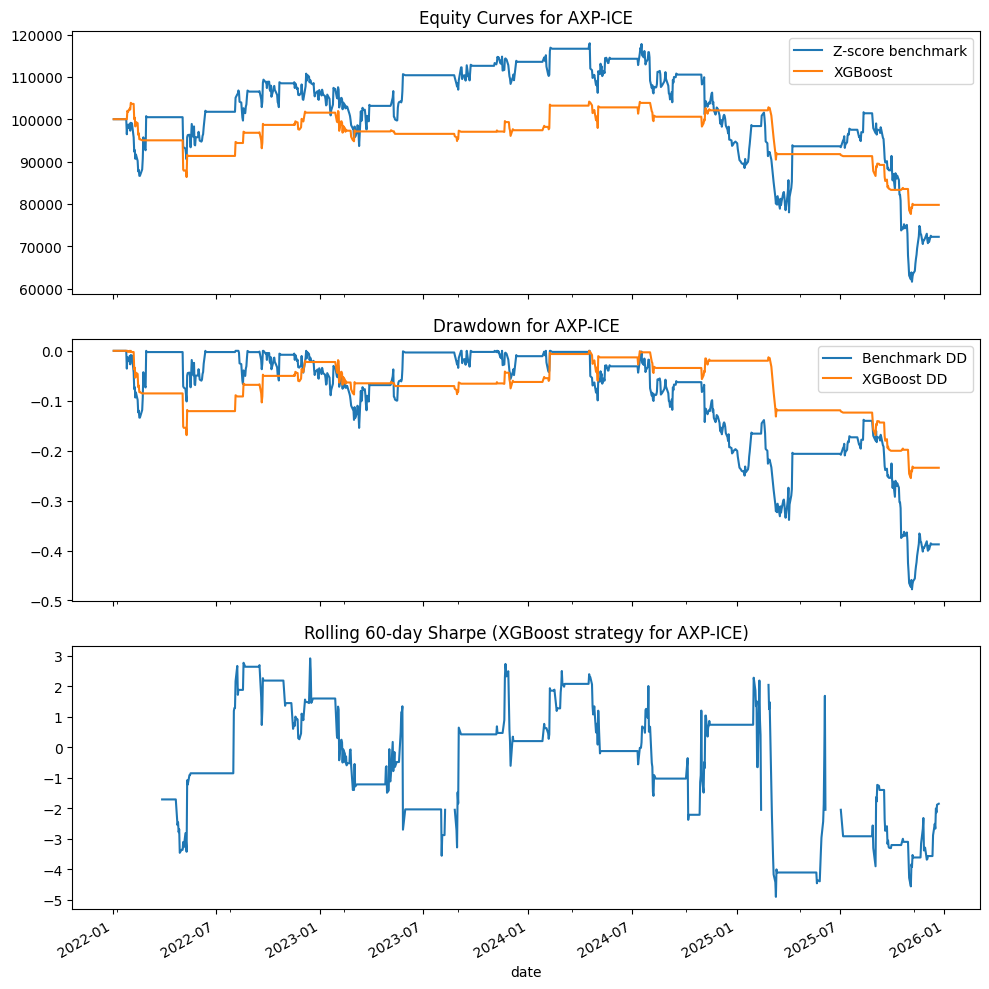


--- XGBoost Feature Importances (Global Model) ---


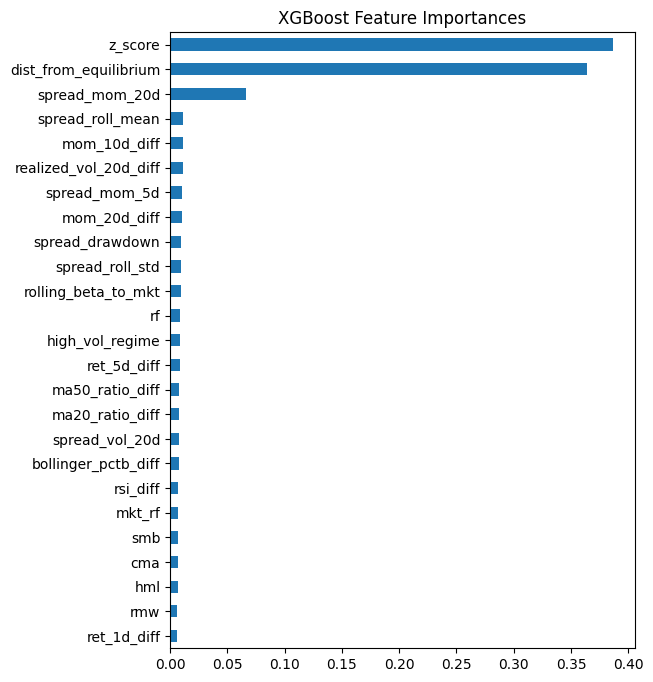

In [ ]:
## Step 8 — See it visually

import matplotlib.pyplot as plt

# Use the pair_name_for_row from the last successful iteration of dppBm8676bPe
# and retrieve the corresponding full BacktestResult objects.
# Ensure pair_name_for_row is defined from the previous cell's loop for plotting.

# For consistent plotting across pairs, let's plot for the first pair in the shortlist as an example.
if not shortlist.empty:
    first_row = shortlist.iloc[0]
    example_pair_name = f"{first_row.asset_1}-{first_row.asset_2}"

    # Retrieve benchmark and ML results for the example pair
    example_bench_result = all_bench_results.get(example_pair_name)
    example_ml_xgboost_result = all_ml_results.get(example_pair_name, {}).get("XGBoost")

    if example_bench_result and example_ml_xgboost_result:
        print(f"\n--- Visualizing results for example pair: {example_pair_name} ---")
        fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

        # Equity Curves
        example_bench_result.equity_curve.plot(ax=axes[0], label="Z-score benchmark")
        example_ml_xgboost_result.equity_curve.plot(ax=axes[0], label="XGBoost")
        axes[0].legend(); axes[0].set_title(f"Equity Curves for {example_pair_name}")

        from risk_analysis import drawdown_series
        # Drawdowns
        drawdown_series(example_bench_result.equity_curve).plot(ax=axes[1], label="Benchmark DD")
        drawdown_series(example_ml_xgboost_result.equity_curve).plot(ax=axes[1], label="XGBoost DD")
        axes[1].legend(); axes[1].set_title(f"Drawdown for {example_pair_name}")

        # Rolling Sharpe
        rolling_sharpe(example_ml_xgboost_result.daily_returns).plot(ax=axes[2])
        axes[2].set_title(f"Rolling 60-day Sharpe (XGBoost strategy for {example_pair_name})")
        plt.tight_layout(); plt.show()

        # Feature Importances for XGBoost
        # The xgb_model here is the globally trained model, not pair-specific, so it's fine.
        if 'xgb_model' in globals() and FEATURE_COLUMNS:
            print("\n--- XGBoost Feature Importances (Global Model) ---")
            # Ensure FEATURE_COLUMNS are aligned with feature importances
            if len(xgb_model.feature_importances_) == len(FEATURE_COLUMNS):
                pd.Series(xgb_model.feature_importances_, index=FEATURE_COLUMNS).sort_values().plot.barh(figsize=(6,8))
                plt.title("XGBoost Feature Importances")
                plt.show()
            else:
                print("Mismatch between feature importances length and FEATURE_COLUMNS. Skipping plot.")
        else:
            print("XGBoost model or FEATURE_COLUMNS not found for feature importances plot.")
    else:
        print(f"Backtest results for example pair ({example_pair_name}) not found or incomplete for plotting. Please ensure previous cells ran successfully.")
else:
    print("Shortlist is empty. No pairs to visualize.")

Visualisations


--- Visualisation pour la paire : JNJ-LLY ---


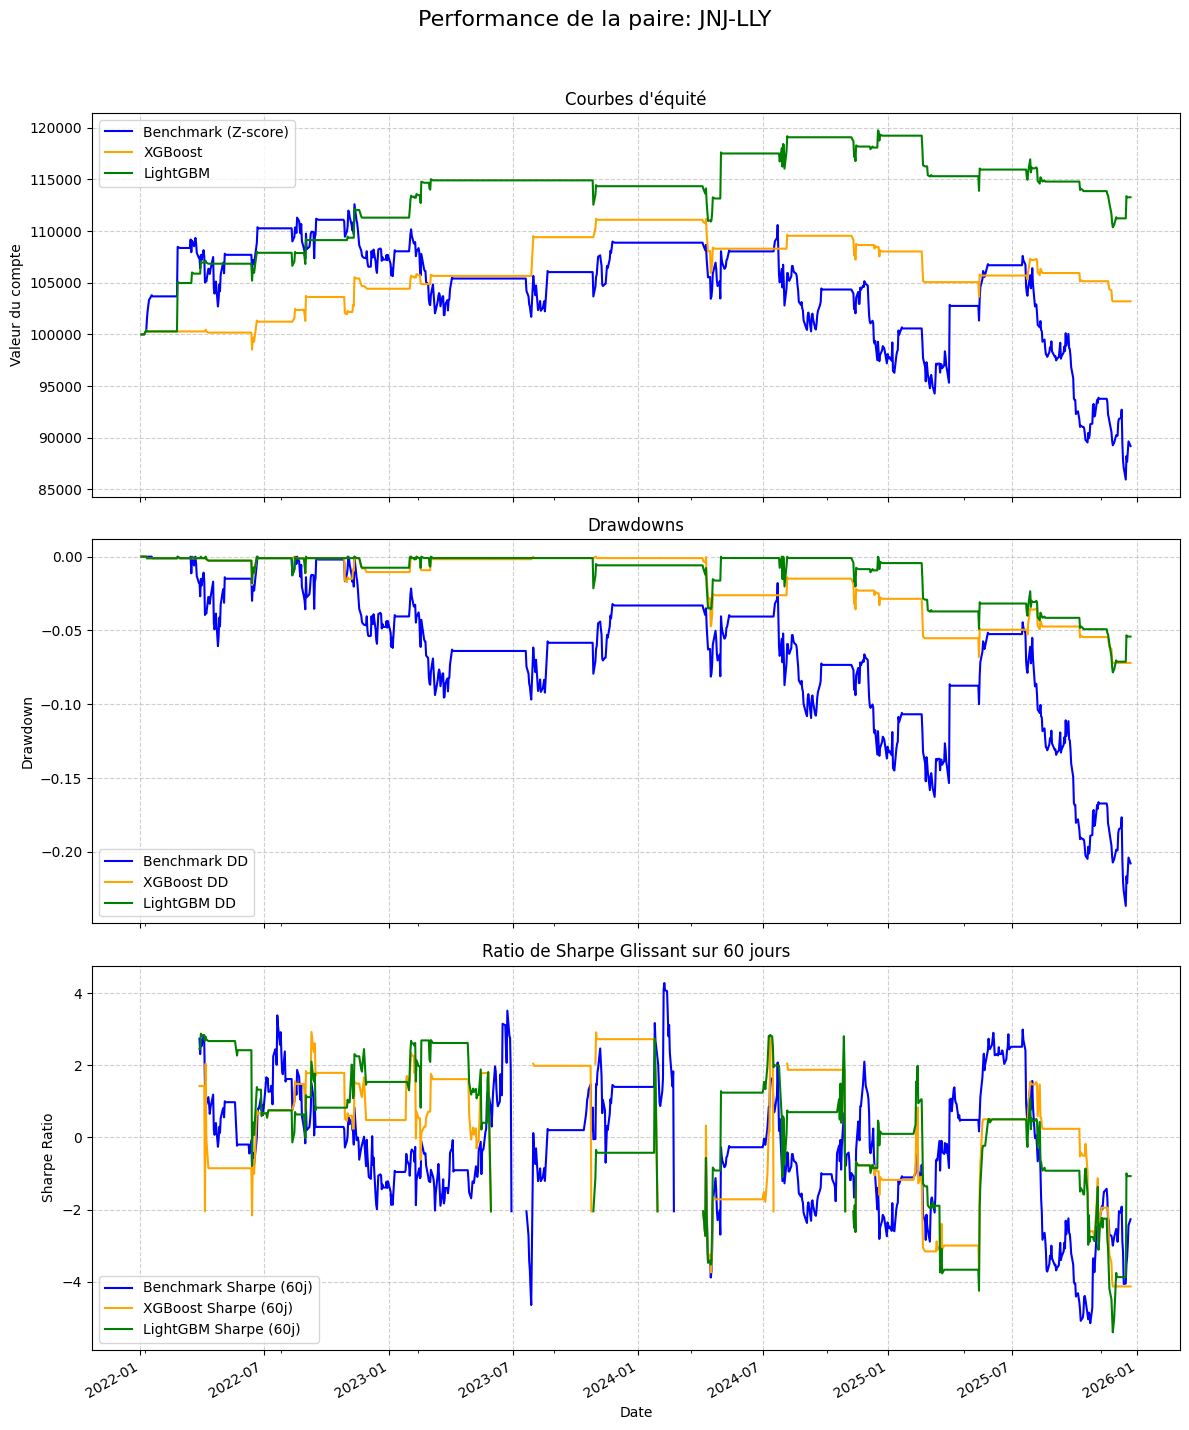

In [ ]:
import matplotlib.pyplot as plt
from risk_analysis import drawdown_series, rolling_sharpe

for i, row in shortlist.iterrows():
    pair_name = f"{row.asset_1}-{row.asset_2}"
    print(f"\n--- Visualisation pour la paire : {pair_name} ---")

    bench_result = all_bench_results.get(pair_name)
    xgb_result = all_ml_results.get(pair_name, {}).get("XGBoost")
    lgbm_result = all_ml_results.get(pair_name, {}).get("LightGBM")

    if not (bench_result and xgb_result and lgbm_result):
        print(f"Résultats de backtest incomplets pour {pair_name}. Sauter les visualisations.")
        continue

    fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
    fig.suptitle(f"Performance de la paire: {pair_name}", fontsize=16)

    # Courbes d'équité
    bench_result.equity_curve.plot(ax=axes[0], label="Benchmark (Z-score)", color='blue')
    xgb_result.equity_curve.plot(ax=axes[0], label="XGBoost", color='orange')
    lgbm_result.equity_curve.plot(ax=axes[0], label="LightGBM", color='green')
    axes[0].set_title("Courbes d'équité")
    axes[0].set_ylabel("Valeur du compte")
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Drawdowns
    drawdown_series(bench_result.equity_curve).plot(ax=axes[1], label="Benchmark DD", color='blue')
    drawdown_series(xgb_result.equity_curve).plot(ax=axes[1], label="XGBoost DD", color='orange')
    drawdown_series(lgbm_result.equity_curve).plot(ax=axes[1], label="LightGBM DD", color='green')
    axes[1].set_title("Drawdowns")
    axes[1].set_ylabel("Drawdown")
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # Sharpe Ratio Glissant sur 60 jours
    rolling_sharpe(bench_result.daily_returns).plot(ax=axes[2], label="Benchmark Sharpe (60j)", color='blue')
    rolling_sharpe(xgb_result.daily_returns).plot(ax=axes[2], label="XGBoost Sharpe (60j)", color='orange')
    rolling_sharpe(lgbm_result.daily_returns).plot(ax=axes[2], label="LightGBM Sharpe (60j)", color='green')
    axes[2].set_title("Ratio de Sharpe Glissant sur 60 jours")
    axes[2].set_xlabel("Date")
    axes[2].set_ylabel("Sharpe Ratio")
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Ajuster pour le suptitle
    plt.show()